In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import numpy as np

#importing the streaming data
CWD = os.getcwd()

song_stat_file = "beef_streams_timeseries.csv"
song_stat_path = os.path.join(CWD, song_stat_file)

headernames = ["rank", 'track_name', 'artist_name', 'streams', 'date', 'source_file']
song_stats = pd.read_csv(filepath_or_buffer=song_stat_path, header=0, names=headernames)

In [2]:
#pulling the data for each of the songs and aggregating them
track_names = np.unique(song_stats['track_name'].values)

song_stats['date'] = pd.to_datetime(song_stats['date'])

stream_history = {}
for name in track_names:
    subset = song_stats.loc[song_stats['track_name'] == name]
    stream_history[name] = {
        'streams': subset['streams'].values,
        'date': subset['date'].values,
        'rank': subset['rank'].values,
    }

print(stream_history)

{'All The Stars (with SZA) - From "Black Panther: The Album"': {'streams': array([1252118, 1269175, 1233797, 1221614, 1202153, 1233091, 1307918,
       1379892, 1430866, 1381426, 1459901, 1750208, 1773692, 1908183,
       2011728, 1963871, 1772357, 1680262, 1739523, 1638829, 1506175,
       1594807, 1366471, 1555312, 1471895, 1462020, 1476592, 1357326,
       1375457, 1173257, 1413910, 1384600, 1471358, 1267074, 1392697,
       1325409, 1311635, 1314441, 1275027, 1370021, 1438240, 1413649,
       1494190, 1232082, 1364007, 1407240, 1306098, 1370687]), 'date': array(['2024-03-26T00:00:00.000000000', '2024-03-28T00:00:00.000000000',
       '2024-04-03T00:00:00.000000000', '2024-04-09T00:00:00.000000000',
       '2024-04-15T00:00:00.000000000', '2024-04-17T00:00:00.000000000',
       '2024-05-01T00:00:00.000000000', '2024-05-02T00:00:00.000000000',
       '2024-05-03T00:00:00.000000000', '2024-05-04T00:00:00.000000000',
       '2024-05-05T00:00:00.000000000', '2024-05-06T00:00:00.00000000

In [3]:
song_stats

,rank,track_name,artist_name,streams,date,source_file
0,4,Like That,"Future, Metro Boomin, Kendrick Lamar",7214071,2024-03-22,regional-global-daily-2024-03-22.csv
1,95,One Dance,"Drake, Wizkid, Kyla",1794279,2024-03-22,regional-global-daily-2024-03-22.csv
2,123,Rich Baby Daddy (feat. Sexyy Red & SZA),"Drake, Sexyy Red, SZA",1593660,2024-03-22,regional-global-daily-2024-03-22.csv
3,4,Like That,"Future, Metro Boomin, Kendrick Lamar",6554059,2024-03-23,regional-global-daily-2024-03-23.csv
4,82,One Dance,"Drake, Wizkid, Kyla",1770490,2024-03-23,regional-global-daily-2024-03-23.csv
...,...,...,...,...,...,...
354,5,Not Like Us,Kendrick Lamar,5650046,2024-07-25,regional-global-daily-2024-07-25.csv
355,64,Like That,"Future, Metro Boomin, Kendrick Lamar",1879581,2024-07-25,regional-global-daily-2024-07-25.csv
356,133,One Dance,"Drake, Wizkid, Kyla",1476354,2024-07-25,regional-global-daily-2024-07-25.csv
357,156,"All The Stars (with SZA) - From ""Black Panther...","Kendrick Lamar, SZA",1370687,2024-07-25,regional-global-daily-2024-07-25.csv


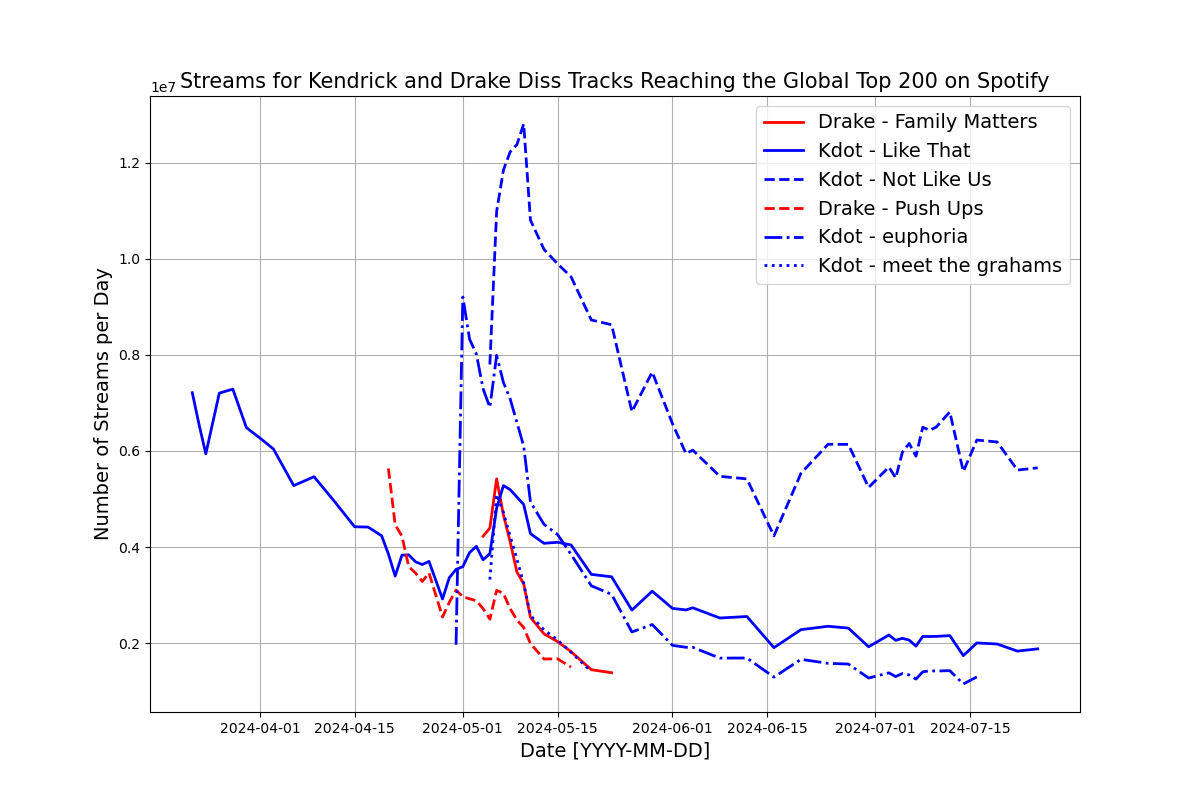

In [9]:
#plotting
%matplotlib widget

title_fontsize=15
axis_label_fontsize = 14
axes_fontsize=13

plt.close('all')
plt.figure(figsize=(12, 8))

songs = {
    "Family Matters": {'artist': 'Drake', 'ls': 'solid', 'color': 'red'}, 
    "Like That": {'artist': 'Kdot', 'ls': 'solid', 'color': 'blue'},
    'Not Like Us': {'artist': 'Kdot', 'ls': 'dashed', 'color': 'blue'},
    'Push Ups': {'artist': 'Drake', 'ls': 'dashed', 'color': 'red'},
    'euphoria': {'artist': 'Kdot', 'ls': 'dashdot', 'color': 'blue'},
    'meet the grahams': {'artist': 'Kdot', 'ls': 'dotted', 'color': 'blue'}
}

for name in track_names:
    if name not in ['Family Matters', 'Like That', 'Not Like Us', 'Push Ups', 'euphoria', 'meet the grahams']: continue
    else: plt.plot(stream_history[name]['date'], 
                   stream_history[name]['streams'], 
                   label=f'{songs[name]['artist']} - {name}',
                   ls=f'{songs[name]['ls']}',
                   color=f'{songs[name]['color']}',
                   lw=2)

plt.title("Streams for Kendrick and Drake Diss Tracks Reaching the Global Top 200 on Spotify", fontsize=title_fontsize)
plt.legend(loc='best', fontsize=axis_label_fontsize)
plt.xlabel('Date [YYYY-MM-DD]', fontsize=axis_label_fontsize)
plt.ylabel("Number of Streams per Day", fontsize=axis_label_fontsize)
plt.rcParams['axes.labelsize'] = axes_fontsize

plt.grid(True)

plt.show()

[      0.       0.       0.       0.       0.       0.       0.       0.
       0.       0.       0.       0.       0.       0. 5635551. 4463687.
 4225998. 3593277. 3459772. 3282535. 3461004. 2542634. 2847902. 3105060.
 2964326. 2921287. 2883925. 6941133. 6894583. 8517203. 7708545. 6826713.
 5958845. 5557797. 4525250. 3860313. 3704459. 3321134. 1445455. 1382648.
       0.       0.       0.       0.       0.       0.       0.       0.
       0.       0.       0.       0.       0.       0.       0.       0.
       0.       0.       0.       0.       0.       0.       0.       0.
       0.       0.] <class 'numpy.ndarray'>


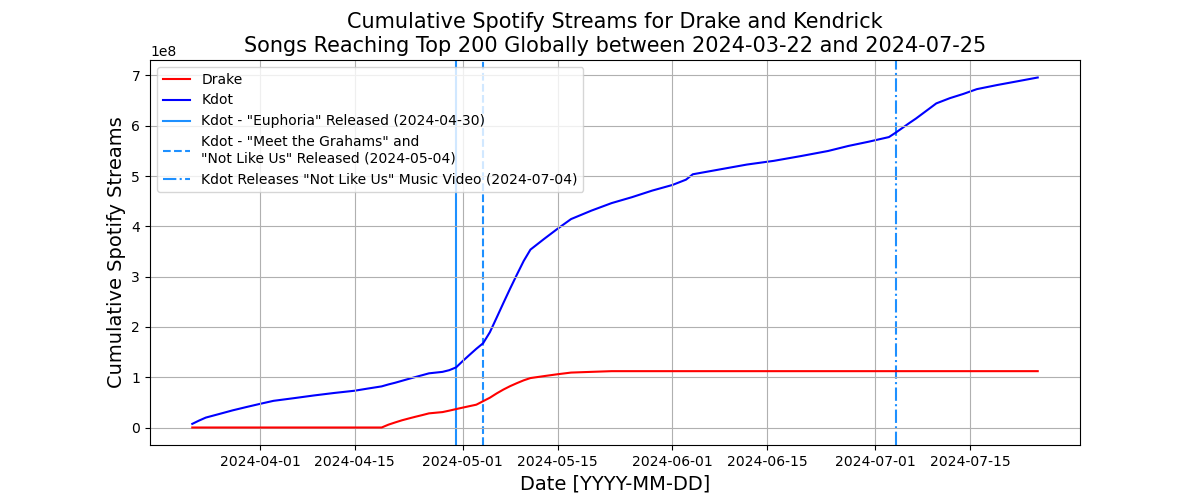

In [25]:

plt.close('all')

plt.figure(figsize=(12, 5))
plt.title("Cumulative Spotify Streams for Drake and Kendrick\nSongs Reaching Top 200 Globally between 2024-03-22 and 2024-07-25", fontsize=title_fontsize)

#get the set up for accumulating the streams across the dates
dates = stream_history['Like That']['date']
drake_streams = np.zeros_like(stream_history['Like That']['date'], dtype=float)
kdot_streams = np.copy(drake_streams)

#going through the tracks
for name in track_names:
    if name not in ['Family Matters', 'Like That', 'Not Like Us', 'Push Ups', 'euphoria', 'meet the grahams']: continue
    else: 
        artist = songs[name]['artist']
        
        song_dates = stream_history[name]['date']
        song_streams = stream_history[name]['streams']

        #for each date, find the corresponding array element for drake or kendrick and add them
        for date, streams in zip(song_dates, song_streams):
            idx = np.where(dates == date)[0]
            if len(idx) == 0:
                print("Nothing returned from np.where to define idx.")
                print(f"\tFail info: {name}, {date}, {streams}")
                continue

            if artist == 'Drake':
                drake_streams[idx[0]] += streams
            elif artist == 'Kdot':
                kdot_streams[idx[0]] += streams

#getting cumulative distribution for each
print(drake_streams, type(drake_streams))
drake_cumulative = np.cumsum(drake_streams)
kdot_cumulative = np.cumsum(kdot_streams)

#plotting
plt.plot(dates, drake_cumulative, color=songs['Family Matters']['color'],
         label='Drake', zorder=2)
plt.plot(dates, kdot_cumulative, color=songs['Like That']['color'],
         label='Kdot', zorder=1)

plt.axvline(x=pd.to_datetime('2024-04-30'), color='dodgerblue', zorder=0,
            label='Kdot - "Euphoria" Released (2024-04-30)')

plt.axvline(x=pd.to_datetime('2024-05-04'), color='dodgerblue', zorder=0, ls='--',
            label='Kdot - "Meet the Grahams" and\n"Not Like Us" Released (2024-05-04)')

plt.axvline(x=pd.to_datetime('2024-07-04'), color='dodgerblue', zorder=0, ls='-.',
            label='Kdot Releases "Not Like Us" Music Video (2024-07-04)')

plt.legend(loc='upper left', fontsize=10)
plt.xlabel('Date [YYYY-MM-DD]', fontsize=axis_label_fontsize)
plt.ylabel("Cumulative Spotify Streams", fontsize=axis_label_fontsize)
plt.rcParams['axes.labelsize'] = axes_fontsize

# plt.yscale('log')
plt.grid(True)

plt.show()
